In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Define some constants
volume = 4e-9 * 4e-9 * 2e-9 # m3
area = 4e-9 * 2e-9 # m2
m = 40e-3 # mass particle in kg/mol
Na = 6.022e23 # Avogadro
kcal_to_j = 4184.0 # Convert factor
degree = 2 # Degree for polynomial fit
f0_real = 0.01 # force applied on each particle kcal/mol/A
f0_SI = f0_real * kcal_to_j * 1e10 / Na # N

# Load MD data

md_data = np.loadtxt("MD/number_and_v_vs_mu.dat")
mu_real, number, v_real = md_data.T # kcal/mol, 0, A/fs

# Quantities in SI units
mu_SI = mu_real * kcal_to_j
v_SI = v_real * 1e-10/1e-15
rho_SI = number/volume # m-3
total_force = rho_SI * f0_SI * volume # N
total_flux = rho_SI * v_SI * area # 1 / s
M_SI = total_flux / total_force # transport coefficient in 1/s/N = s / kg / m

# Fits
coeffs_M_vs_mu = np.polyfit(mu_SI, M_SI, degree)
coeffs_rho_vs_mu = np.polyfit(mu_SI, rho_SI, degree)
coeffs_mu_vs_M = np.polyfit(M_SI, mu_SI, degree)
coeffs_mu_vs_rho = np.polyfit(rho_SI, mu_SI, degree)

# Save fitting paramters
with open("M_vs_mu_fit.txt", "w") as f:
    f.write(f"{degree}\n")
    for c in coeffs_M_vs_mu:
        f.write(f"{c}\n")

with open("rho_vs_mu_fit.txt", "w") as f:
    f.write(f"{degree}\n")
    for c in coeffs_rho_vs_mu:
        f.write(f"{c}\n")

with open("mu_vs_M_fit.txt", "w") as f:
    f.write(f"{degree}\n")
    for c in coeffs_mu_vs_M:
        f.write(f"{c}\n")

with open("mu_vs_rho_fit.txt", "w") as f:
    f.write(f"{degree}\n")
    for c in coeffs_mu_vs_rho:
        f.write(f"{c}\n")

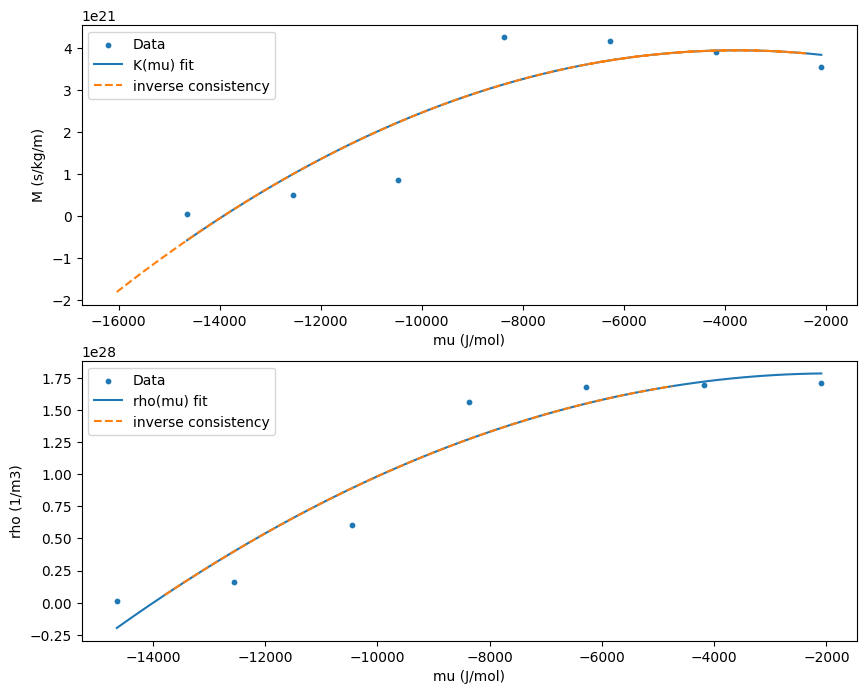

In [34]:
# Test the fit
poly_K_vs_mu = np.poly1d(coeffs_M_vs_mu)
poly_rho_vs_mu = np.poly1d(coeffs_rho_vs_mu)
poly_mu_vs_K = np.poly1d(coeffs_mu_vs_M)
poly_mu_vs_rho = np.poly1d(coeffs_mu_vs_rho)

# Grids
mu_grid = np.linspace(min(mu_SI), max(mu_SI), 300)
K_grid = np.linspace(min(M_SI), max(M_SI), 300)
rho_grid = np.linspace(min(rho_SI), max(rho_SI), 300)

# Forward fits
K_fit = poly_K_vs_mu(mu_grid)
rho_fit = poly_rho_vs_mu(mu_grid)

# K consistency
mu_from_K = poly_mu_vs_K(K_grid)
K_back = poly_K_vs_mu(mu_from_K)

# rho consistency
mu_from_rho = poly_mu_vs_rho(rho_grid)
rho_back = poly_rho_vs_mu(mu_from_rho)

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.scatter(mu_SI, M_SI, s=10, label="Data")
plt.plot(mu_grid, K_fit, label="K(mu) fit")
plt.plot(mu_from_K, K_back, "--", label="inverse consistency")
plt.xlabel("mu (J/mol)")
plt.ylabel("M (s/kg/m)")
plt.legend()
plt.subplot(2, 1, 2)
plt.scatter(mu_SI, rho_SI, s=10, label="Data")
plt.plot(mu_grid, rho_fit, label="rho(mu) fit")
plt.plot(mu_from_rho, rho_back, "--", label="inverse consistency")
plt.xlabel("mu (J/mol)")
plt.ylabel("rho (1/m3)")
plt.legend()